# Chunk location sanity check

Plots the **whole-globe location** of the single native 720×720 LLC4320 chunk
selected by `configs/transfer/run_chunks_monterey_bay.yaml`:

* the whole globe with coastlines,
* a ⭐ at the requested `lat,lon`,
* a **red box** = the actual native-grid perimeter of the chosen chunk,
* plus a zoomed panel so the (small) box is visible.

Notes
-----
* Run this **on the MIT server** — it reads `data.MIT_data_path` from the config.
* It loads **only the grid** (`XC`/`YC`); no field data is read.
  (`resolve_chunk` does pull the full `XC`/`YC` into memory, ~2 GB, to find the
  nearest cell — that's the grid, and it's fine on the MIT machine.)
* Reuses the transfer module: `config.load_config`, `zarr_io.open_source`,
  `chunk_selection.resolve_chunk`.
* Requires **cartopy** for coastlines: `conda install -c conda-forge cartopy`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def _find_repo_root(start=None):
    """Walk up from *start* (or cwd) to the dir containing pyproject.toml."""
    p = Path(start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists():
            return cand
    raise RuntimeError(f"Could not locate repo root (pyproject.toml) above {p}")


REPO = _find_repo_root()
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dbof.transfer import config as tconfig
from dbof.transfer import zarr_io, chunk_selection

print("repo root:", REPO)

repo root: /orcd/home/002/lahoffma/git/llc4320-native-grid-preprocessing


In [2]:
# --- Load the chunk config and resolve the lat/lon -> native 720x720 chunk ---
CONFIG = REPO / "configs/transfer/run_chunks_monterey_bay.yaml"
cfg = tconfig.load_config(str(CONFIG))
loc = cfg.transfer.location
print(f"Chunk '{loc.chunk_name}' requested at lat={loc.lat}, lon={loc.lon}")

# Open the native source store (lazy). We only ever touch the grid coords XC/YC.
ds = zarr_io.open_source(cfg.data.MIT_data_path)

# resolve_chunk loads XC/YC (the grid) and returns the enclosing 720x720 chunk.
sel = chunk_selection.resolve_chunk(ds, loc.lat, loc.lon, tile=cfg.transfer.tile_i)
sel

Chunk 'monterey_bay' requested at lat=36.8, lon=-121.9


ChunkSelection(face_idx=10, j0=0, i0=2880, tile=720, nearest_j=292, nearest_i=2976, nearest_lat=36.801422119140625, nearest_lon=-121.90625)

In [3]:
print(f"face         = {sel.face_idx}")
print(f"j slice      = {sel.j0}:{sel.j0 + sel.tile}")
print(f"i slice      = {sel.i0}:{sel.i0 + sel.tile}")
print(f"nearest cell = (j={sel.nearest_j}, i={sel.nearest_i})")
print(f"nearest lon/lat = ({sel.nearest_lon:.4f}, {sel.nearest_lat:.4f})")

face         = 10
j slice      = 0:720
i slice      = 2880:3600
nearest cell = (j=292, i=2976)
nearest lon/lat = (-121.9062, 36.8014)


In [4]:
# --- Build the chunk perimeter from the grid lon/lat (720x720, tiny read) ---
def _wrap180(x):
    """Normalise longitude to [-180, 180) for plotting."""
    return ((np.asarray(x) + 180.0) % 360.0) - 180.0

clon = _wrap180(ds["XC"].isel(face=sel.face_idx, j=sel.j_slice, i=sel.i_slice).values)
clat = ds["YC"].isel(face=sel.face_idx, j=sel.j_slice, i=sel.i_slice).values

# Closed perimeter of the block: top row, right col, bottom row (rev), left col (rev).
perim_lon = np.concatenate([clon[0, :], clon[:, -1], clon[-1, ::-1], clon[::-1, 0]])
perim_lat = np.concatenate([clat[0, :], clat[:, -1], clat[-1, ::-1], clat[::-1, 0]])

req_lon, req_lat = _wrap180(loc.lon), loc.lat
near_lon, near_lat = _wrap180(sel.nearest_lon), sel.nearest_lat
print("chunk lon range:", perim_lon.min(), perim_lon.max())
print("chunk lat range:", perim_lat.min(), perim_lat.max())

chunk lon range: -127.989586 -113.010414
chunk lat range: 26.658613 38.266804


/home/lahoffma/miniforge3/envs/llc/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/lahoffma/miniforge3/envs/llc/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


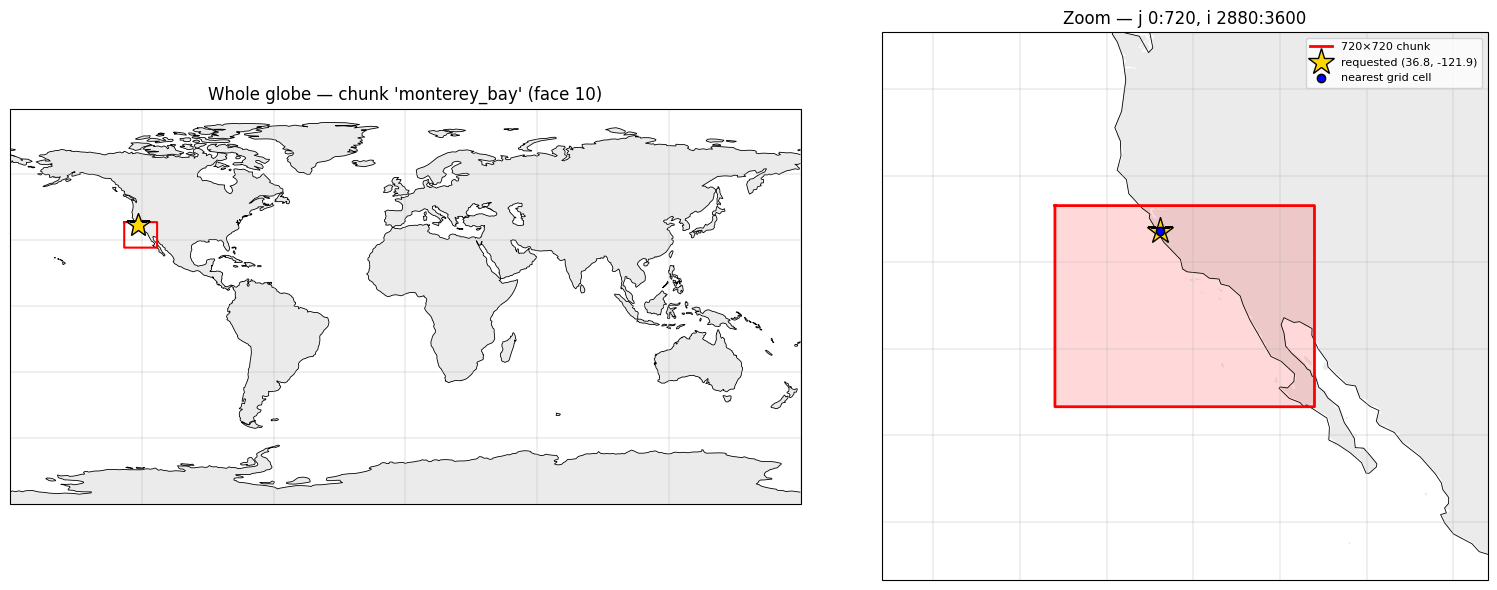

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()
fig, (ax_g, ax_z) = plt.subplots(
    1, 2, figsize=(16, 6), subplot_kw={"projection": proj}
)

for ax in (ax_g, ax_z):
    ax.add_feature(cfeature.LAND, facecolor="0.92")
    ax.coastlines(resolution="110m", linewidth=0.6)
    ax.gridlines(draw_labels=False, linewidth=0.3, color="0.7")

# --- Whole globe ---
ax_g.set_global()
ax_g.plot(perim_lon, perim_lat, color="red", lw=1.5, transform=proj)
ax_g.plot(req_lon, req_lat, marker="*", color="gold", markersize=18,
          markeredgecolor="k", linestyle="none", transform=proj)
ax_g.set_title(f"Whole globe \u2014 chunk '{loc.chunk_name}' (face {sel.face_idx})")

# --- Zoom (so the 720x720 box is visible) ---
pad = 10.0
ax_z.set_extent([perim_lon.min() - pad, perim_lon.max() + pad,
                 perim_lat.min() - pad, perim_lat.max() + pad], crs=proj)
ax_z.fill(perim_lon, perim_lat, color="red", alpha=0.15, transform=proj)
ax_z.plot(perim_lon, perim_lat, color="red", lw=2, transform=proj,
          label="720\u00d7720 chunk")
ax_z.plot(req_lon, req_lat, marker="*", color="gold", markersize=20,
          markeredgecolor="k", linestyle="none", transform=proj,
          label=f"requested ({loc.lat}, {loc.lon})")
ax_z.plot(near_lon, near_lat, marker="o", color="blue", markersize=6,
          markeredgecolor="k", linestyle="none", transform=proj,
          label="nearest grid cell")
ax_z.set_title(f"Zoom \u2014 j {sel.j0}:{sel.j0 + sel.tile}, i {sel.i0}:{sel.i0 + sel.tile}")
ax_z.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()